# Exploratory Data Analysis and Figure Generation

## I: Load and Clean Data

In [1]:
# Author information
__author__ = "Kevin McCoy"
__copyright__ = "Copyright 2024, Ahmad"
__credits__ = ["Kevin McCoy", "Christine Peterson", "Moiz Ahmad"]
__license__ = "MIT"
__version__ = "1.0.0"
__maintainer__ = "Kevin McCoy"
__email__ = ["kmccoy1@rice.edu", "cbpeterson@mdanderson.org", "MAhmad@mdanderson.org"]
__status__ = "released"
__date__ = "2024-03-18" # Last modified date

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import random
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap 

In [3]:
# Read in data
FILENAME = "./data/og_data.xlsx"
df_og = pd.read_excel(FILENAME)

# Print first 5 columns of dataframe
df_og.head()

,Unnamed: 0,Study ID,ParticleNumber in Study,Num_slices,Area,Mean,StdDev,X,Y,XM,...,AR,Round,Solidity,Exp_Mean,Exp_StdDev,Exp_Skew,Exp_Kurt,label0,label1,label2
0,0,1,1,240,381.818,127.998,65.816,282.295,150.214,284.920,...,3.913,0.256,0.710,-147.231,269.657,-1.770,2.136,1,0,0
1,1,1,2,240,440.161,127.955,75.097,156.986,164.777,153.283,...,3.728,0.268,0.691,-258.091,334.314,-1.064,-0.618,1,0,0
2,2,1,3,240,218.604,206.139,109.257,221.809,184.493,223.395,...,2.434,0.411,0.705,76.749,148.970,1.256,2.419,1,0,0
3,3,1,4,240,2068.610,195.601,66.940,280.191,226.946,279.497,...,1.190,0.840,0.717,-110.007,422.136,-0.802,-1.127,1,0,0
4,4,1,5,240,1042.059,335.411,70.303,213.803,219.408,214.844,...,1.364,0.733,0.739,-159.458,452.358,-0.540,-1.336,1,0,0


In [4]:
# Set random seed
random.seed(8675309)

# Extract Dependent Variable of Interest
labels_data = df_og[['label0','label1','label2']].to_numpy()

# Extract individual label columns
y0 = labels_data[:,0]
y1 = labels_data[:,1]
y2 = labels_data[:,2]

# Extract single vector of class number
y_class = np.argmax(labels_data, axis=1)

# Clean Data
df = df_og.drop(['label0','label1','label2'], axis=1) # Drop label columns from list of X columns
metadata = df[['Unnamed: 0','Study ID','ParticleNumber in Study','Num_slices']]
df = df.drop(['Unnamed: 0','Study ID','ParticleNumber in Study','Num_slices'], axis=1) # Drop study metadata

# Drop features 
df = df.drop(['Slice', 'Exp_Skew', 'Exp_Kurt'], axis=1) # Missing data in these feature columns

# Export to numpy array
X = df.to_numpy()

# Get study ID
patient = metadata['Study ID'].to_numpy() # Patient number

# Get test and train indices
test_percentage = 0.2 # Edit as you like
num_patients = max(patient)
test_idx = random.sample(range(1, num_patients+1), math.floor(test_percentage*num_patients))
test_rows = metadata['Study ID'].isin(test_idx).to_numpy()

X = X[~test_rows,:]
y0 = y0[~test_rows]

## II: Summary Statistics and EDA

In [5]:
# Downsample class0 and re-do PCA

# Set random seed
np.random.seed(8675309)

# Find rows belonging to each class
rows_0 = np.where(y0 == 1)[0]
rows_1 = np.where(y0 == 0)[0]

# Pick 100 random objects from each class
new_rows_0 = np.random.choice(rows_0, 100)
new_rows_1 = np.random.choice(rows_1, 100)


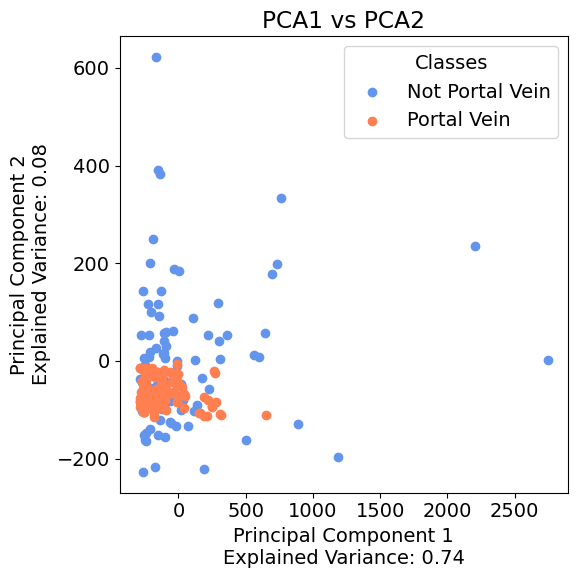

In [6]:
# Perform PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Variance explained by each component
explained_variance = pca.explained_variance_ratio_
plt.rcParams.update({'font.size': 14})

# Create a 1x3 figure with subplots
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
cmap = ListedColormap(["cornflowerblue", "coral"])

# Plot PCA1 vs PCA2
scatter1 = ax.scatter(principal_components[new_rows_0, 0], principal_components[new_rows_0, 1], c="cornflowerblue", label="Not Portal Vein")
scatter2 = ax.scatter(principal_components[new_rows_1, 0], principal_components[new_rows_1, 1], c="coral", label="Portal Vein")
ax.set_xlabel(f'Principal Component 1\nExplained Variance: {explained_variance[0]:.2f}')
ax.set_ylabel(f'Principal Component 2\nExplained Variance: {explained_variance[1]:.2f}')
ax.set_title('PCA1 vs PCA2')
ax.legend(title="Classes")

# Adjust layout and show the plots
plt.tight_layout()
plt.savefig('./figures/pca.pdf', dpi=600)
plt.show()

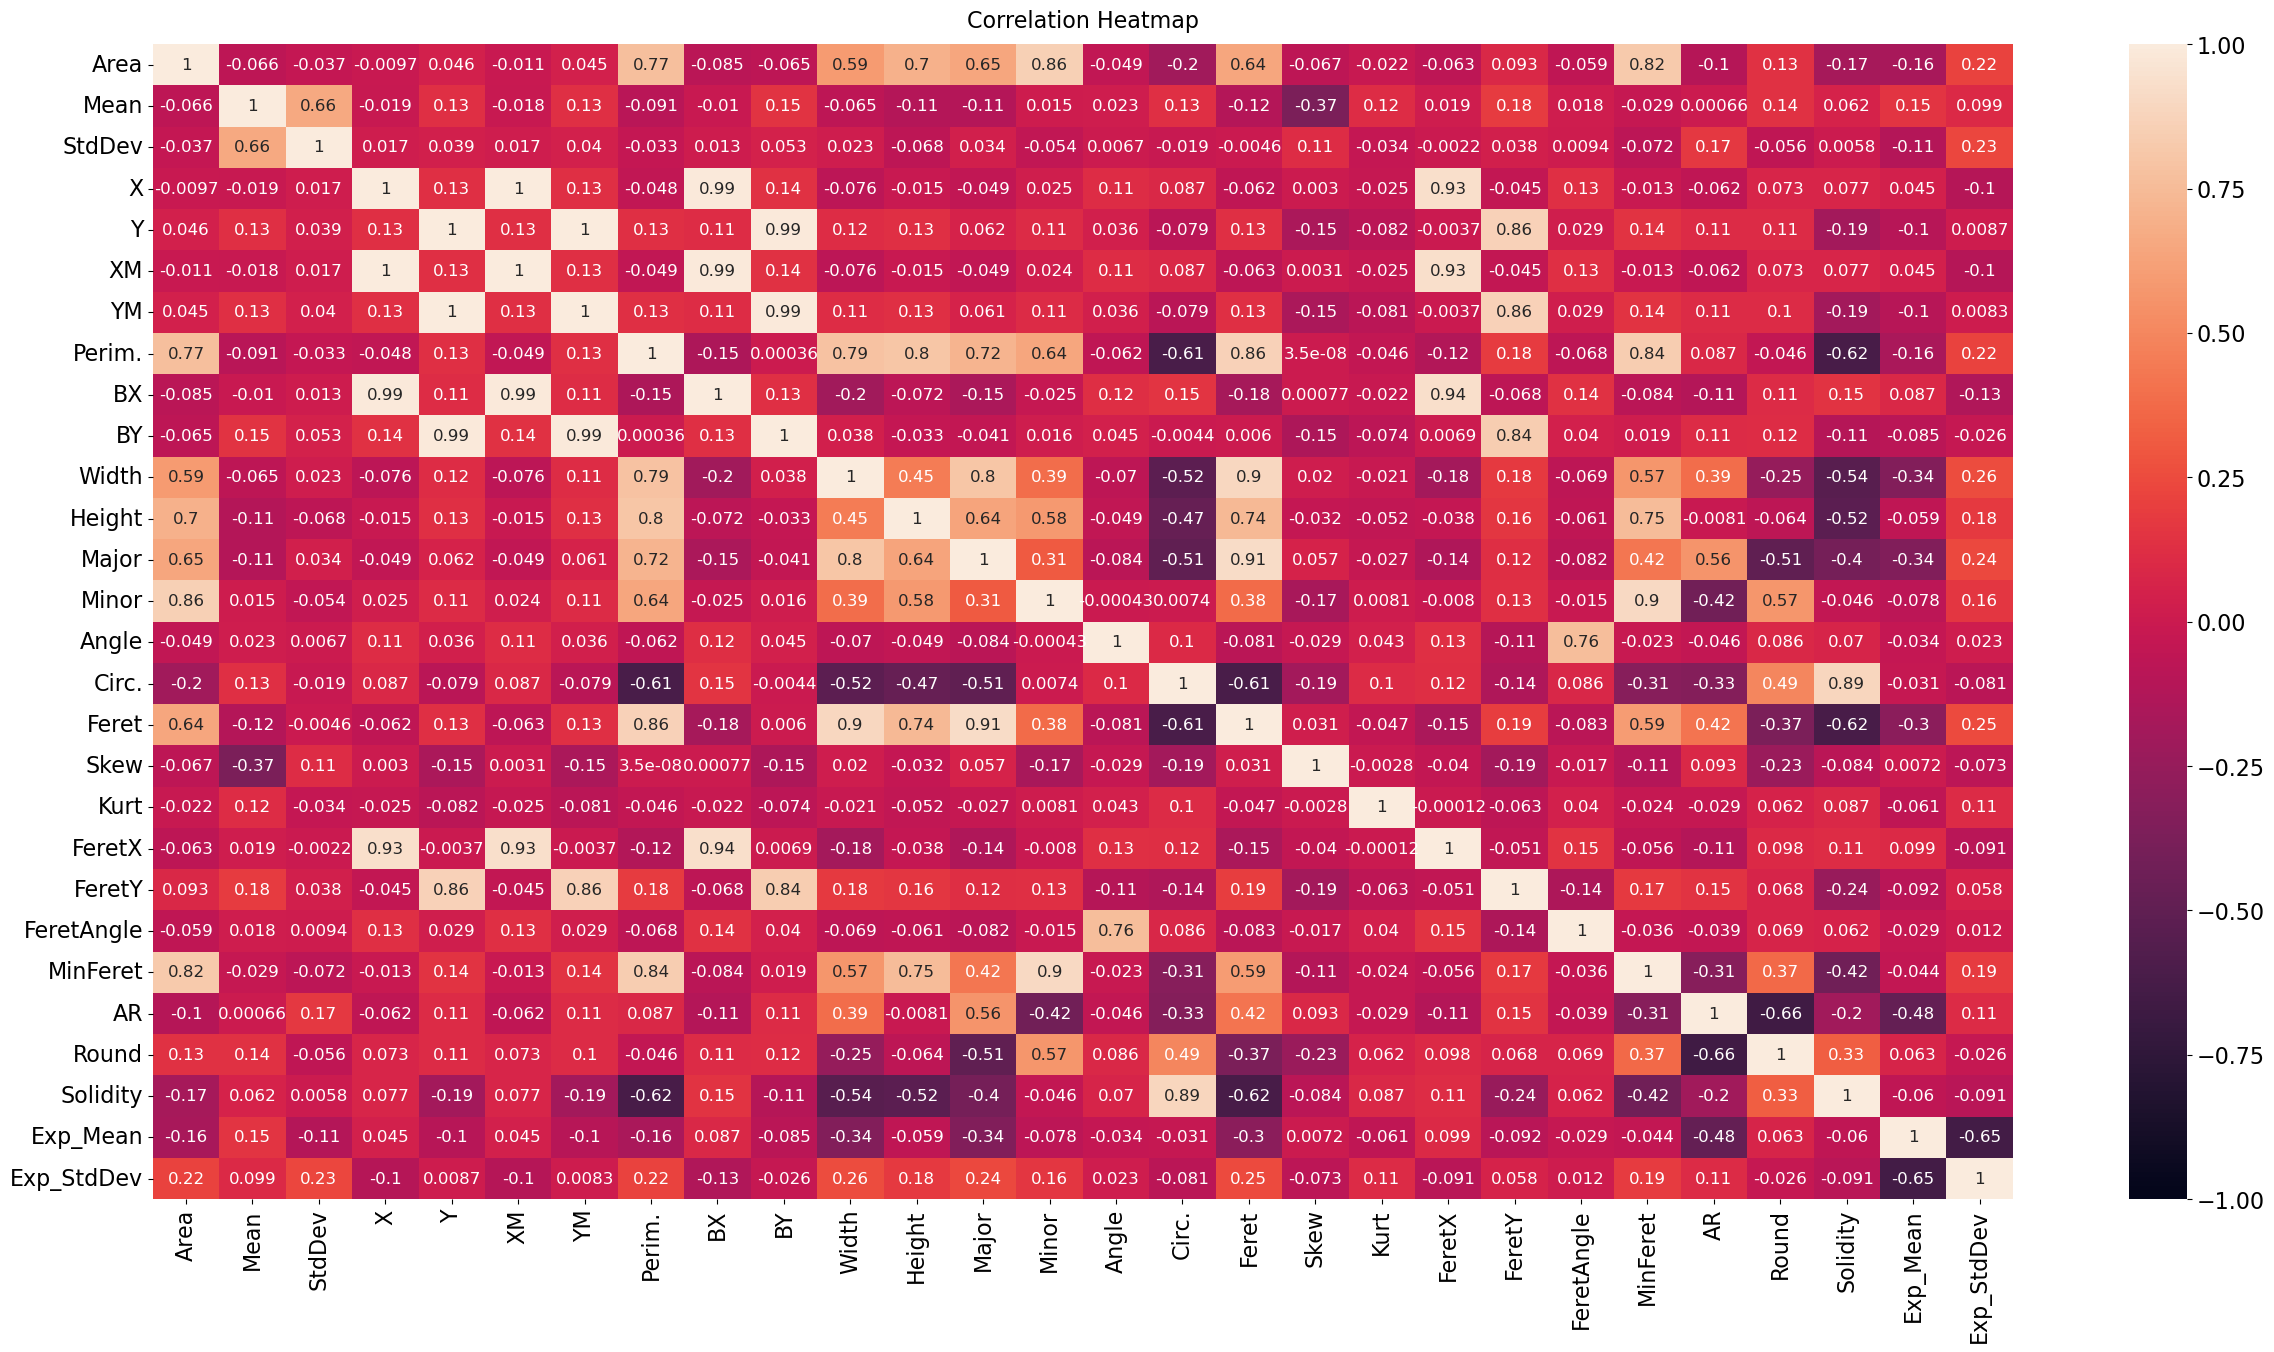

In [7]:
# Correlation heatmap

plt.rcParams.update({'font.size': 16})

new_df = df.iloc[~test_rows, :]

plt.figure(figsize=(30, 15))
heatmap = sns.heatmap(new_df.corr(), vmin=-1, vmax=1, annot=True, annot_kws={"fontsize":12})
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':16}, pad=12);


plt.savefig('./figures/heatmap.pdf', dpi=300, bbox_inches='tight')